In [6]:
import os
import sys
from pathlib import Path

if sys.platform == "win32":
    prefix_dir = Path(sys.prefix).resolve()
    dll_candidates = [
        prefix_dir,
        prefix_dir / "Library" / "bin",
        prefix_dir / "Scripts",
        prefix_dir / "Lib" / "site-packages" / "torch" / "lib",
    ]
    for dll_dir in dll_candidates:
        if dll_dir.exists():
            os.environ["PATH"] = f"{dll_dir};" + os.environ.get("PATH", "")
            try:
                os.add_dll_directory(str(dll_dir))
            except Exception:
                pass

from pycaret.regression import load_model, predict_model
import pandas as pd
from ax.service.managed_loop import optimize
import numpy as np
from ax.service.ax_client import AxClient
from ax.service.utils.instantiation import ObjectiveProperties
import random

SEED = 43
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
except Exception:
    pass

In [7]:
from pathlib import Path

# 1. pycaret에서 기존에 구축한 모델 불러오기
project_dir = Path(r"d:/1_DX/PSA_v2")
model_R = load_model(str(project_dir / 'et_saved_220525_test3'))
model_P = load_model(str(project_dir / 'et2_saved_220525_test3'))
model_V = load_model(str(project_dir / 'et3_saved_220525_test3'))

# input data 불러오기
input_df = pd.read_csv(project_dir / 'Bays_data_initial 10_251007.csv', encoding='cp949')

# base와 columns 정의
base = input_df.iloc[0].copy()
columns = input_df.columns

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [8]:
# 이전 논문에서 정의한 obj 값 구현
def pycaret_predict(params):
    # 파라미터 매핑
    param_map = {
        "Feed_rate_SLPM": "Feed rate (SLPM)",
        "Rinse_rate_SLPM": "Rinse rate (SLPM)",
        "Pad_bar": "Pad (bar)",
        "Pde_bar": "Pde (bar)"
    }
    updated_base = base.copy()
    for k, v in params.items():
        updated_base[param_map[k]] = v
    input_row_updated = {col: updated_base[col] for col in columns}
    input_df_pred = pd.DataFrame([input_row_updated])

    # 모델 예측
    pred_R = predict_model(model_R, data=input_df_pred)
    pred_P = predict_model(model_P, data=input_df_pred)
    pred_V = predict_model(model_V, data=input_df_pred)

    # obj 계산 (이전 논문 참조)
    Feed_CO = 0.2 * input_df_pred['Feed rate (SLPM)'] * 60 / (10**3 * 0.082057 * 273.15)
    Product_CO = Feed_CO * pred_R['prediction_label'] / 100
    Productivity = Product_CO*10**3*24/(4*578.36/10**3)

    k_comp = 1.4 * (0.517 + 0.253) + 1.28 * 0.23
    k_vc = 1.4
    mu = 0.75
    Feed_Compressor = 2.78e-4 * k_comp / (k_comp - 1) * 100 * input_df_pred['Pad (bar)'] / mu / mu / input_df_pred['Pad (bar)'] ** ((k_comp - 1) / k_comp - 1)
    Rinse_Compressor = 2.78e-4 * k_vc / (k_vc - 1) * 100 * input_df_pred['Pad (bar)'] / mu / mu / input_df_pred['Pad (bar)'] ** ((k_vc - 1) / k_vc - 1)
    Vacuum_Pump = 2.78e-4 * k_vc / (k_vc - 1) * 100 * mu / mu / (1 / input_df_pred['Pde (bar)']) ** ((k_vc - 1) / k_vc - 1)
    Electricity = Feed_Compressor + Rinse_Compressor * (input_df_pred['Rinse rate (SLPM)'] / input_df_pred['Feed rate (SLPM)']) + Vacuum_Pump * (pred_V['prediction_label'] / input_df_pred['Feed rate (SLPM)'])

    CO_Low = (pred_P['prediction_label'] / 100) * (2411 / 11000) * 0.528
    CO_High = 15.49008 * np.exp(0.75093 * (pred_P['prediction_label'] - 98))
    CO_Price = np.maximum(CO_Low, CO_High)

    Fee_gas = (20 / 100) * (2411 / 11000) * 0.528
    Elec_price = 0.1
    Propit = CO_Price * Product_CO * 22.4
    Cost = input_df_pred['Feed rate (SLPM)'] * (60 / 10**3) * Fee_gas
    Opex = (60 / 10**3) * input_df_pred['Feed rate (SLPM)'] * Electricity * Elec_price

    obj = Propit - Cost - Opex
    # 예측값과 obj를 반환하도록 수정
    return {
        'obj': obj.iloc[0],
        'pred_R': pred_R['prediction_label'].iloc[0],
        'pred_P': pred_P['prediction_label'].iloc[0],
        'pred_V': pred_V['prediction_label'].iloc[0],
        'Productivity': Productivity.iloc[0]
    }

In [12]:
# base와 columns 정의
base = input_df.iloc[0].copy()
columns = input_df.columns

# v8.1은 obj 하나만 최대화하는 단일 목적 최적화
objectives_list = ['obj']

# 결과 저장용 리스트
history = []

def evaluation_function(params):
    result = pycaret_predict(params)
    row = {
        **params,
        'pred_R': result['pred_R'],
        'pred_P': result['pred_P'],
        'pred_V': result['pred_V'],
        'obj': result['obj'],
        'Productivity': result['Productivity']
    }
    history.append(row)
    return {'obj': result['obj']}

# AxClient 생성 및 실험 정의
ax_client = AxClient(random_seed=SEED)
objectives_dict = {obj: ObjectiveProperties(minimize=False) for obj in objectives_list}
ax_client.create_experiment(
    name="psa_optimization",
    parameters=[
        {"name": "Feed_rate_SLPM", "type": "range", "bounds": [2, 8], "value_type": "float"},
        {"name": "Rinse_rate_SLPM", "type": "range", "bounds": [0.8, 2.1], "value_type": "float"},
        {"name": "Pad_bar", "type": "range", "bounds": [2.5, 6.4], "value_type": "float"},
        {"name": "Pde_bar", "type": "range", "bounds": [0.05, 0.15], "value_type": "float"},
    ],
    objectives=objectives_dict
)

# 실험 반복
for i in range(100):
    parameters, trial_index = ax_client.get_next_trial()
    obj_result = evaluation_function(parameters)
    ax_client.complete_trial(trial_index=trial_index, raw_data=obj_result)

# 결과 DataFrame 생성
history_df = pd.DataFrame(history)
print(history_df.head())

# 단일 목적 최적화 결과 출력
best_parameters, values = ax_client.get_best_parameters()
print("Best parameters:")
print(best_parameters)
print("Best objective values:")
print(values)

# Ax 내장 분석 시각화는 Graphviz(dot) 실행 파일이 있을 때만 수행
import shutil
if shutil.which("dot"):
    ax_client.compute_analyses(display=True)
else:
    print("Graphviz 'dot' 실행 파일이 없어 Ax 분석 시각화는 건너뜁니다.")

[WARNING 03-23 16:30:38] ax.service.ax_client: Random seed set to 43. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[INFO 03-23 16:30:38] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 03-23 16:30:38] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='GenerationStep_0_Sobol+GenerationStep_1_BoTorch', nodes=[GenerationNode(name='GenerationStep_0_Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='GenerationStep_1_BoTorch'), MinTrials(transition_to='Gener

   Feed_rate_SLPM  Rinse_rate_SLPM   Pad_bar   Pde_bar     pred_R     pred_P  \
0        4.529521         1.883865  4.877970  0.146493  74.385680  99.179212   
1        7.316907         1.027316  2.653568  0.078975  50.346938  91.575585   
2        5.805252         1.534701  5.749405  0.109617  82.447543  91.978932   
3        3.017730         1.333805  3.525011  0.064732  91.899142  87.126114   
4        2.396064         1.738300  3.161351  0.053395  89.230968  94.556979   

     pred_V       obj  Productivity  
0  2.184936  1.399805     18.713674  
1  1.464419 -0.058791     20.460583  
2  2.120238 -0.166804     26.583749  
3  1.369338 -0.047600     15.403139  
4  1.638745 -0.013280     11.874940  
Best parameters:
{'Feed_rate_SLPM': 8.0, 'Rinse_rate_SLPM': 2.0204221336065338, 'Pad_bar': 6.4, 'Pde_bar': 0.05}
Best objective values:
({'obj': 3.998531416292081}, {'obj': {'obj': 3.3316668473259234e-05}})
Graphviz 'dot' 실행 파일이 없어 Ax 분석 시각화는 건너뜁니다.


In [10]:
from datetime import datetime
import os

# Summary 테이블을 CSV로 저장

# 현재 시간 정보 가져오기
current_time = datetime.now().strftime('%Y%m%d_%H%M%S')

ipynb_filename = '260323_PSA_Bayesian_optimization_v8.1_r42'

# CSV 파일명 생성 (노트북과 같은 폴더에 저장)
csv_filename = project_dir / f'{current_time}_{ipynb_filename}_Summary_for_psa_optimization.csv'

# history_df를 CSV로 저장
history_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')

print(f'Summary table saved as: {csv_filename}')

Summary table saved as: d:\1_DX\PSA_v2\20260323_161959_260323_PSA_Bayesian_optimization_v8.1_r42_Summary_for_psa_optimization.csv


In [ ]:
history_df = pd.read_csv(csv_filename, encoding='utf-8-sig')

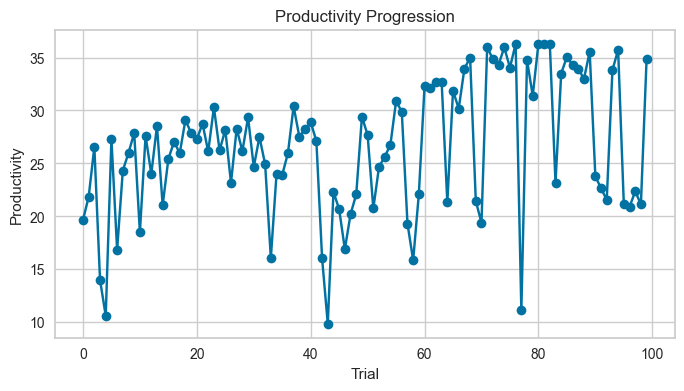

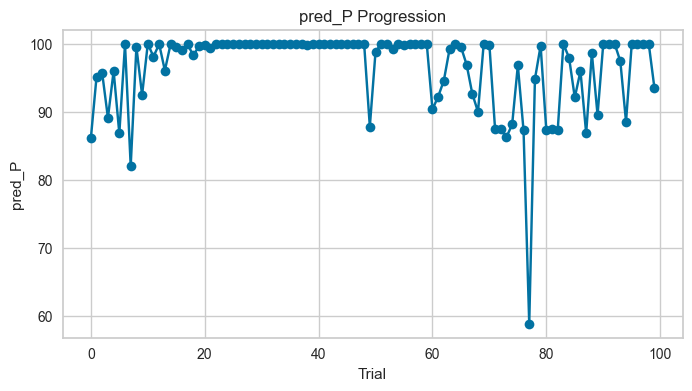

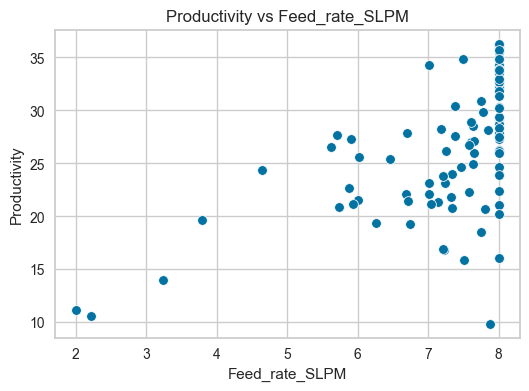

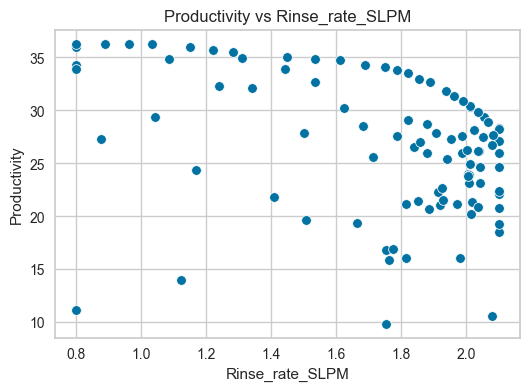

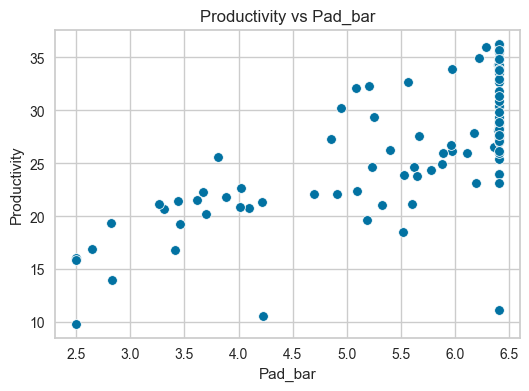

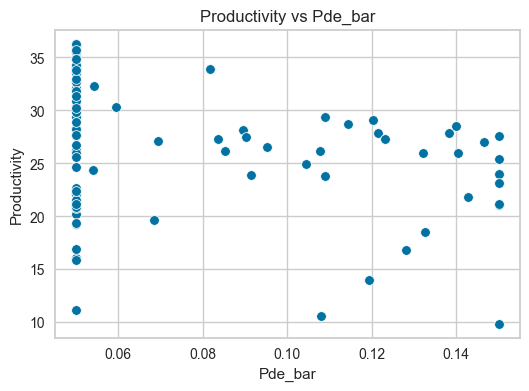

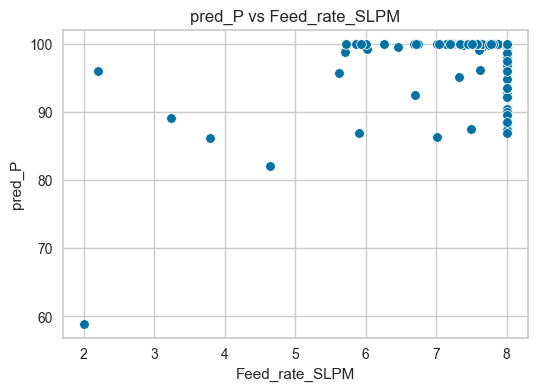

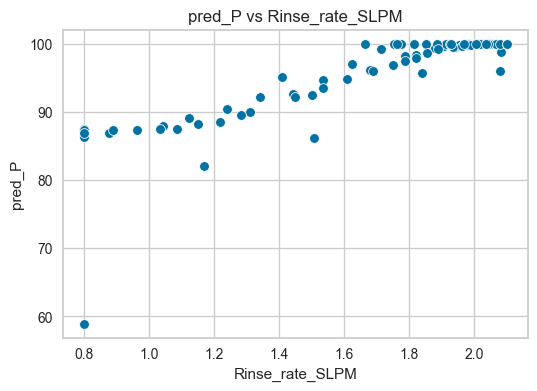

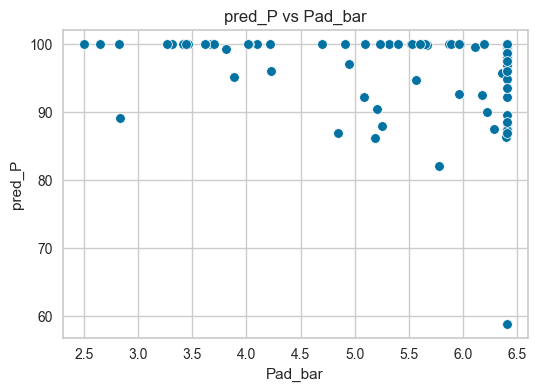

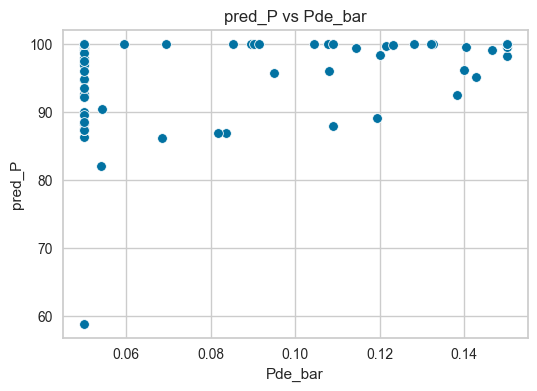

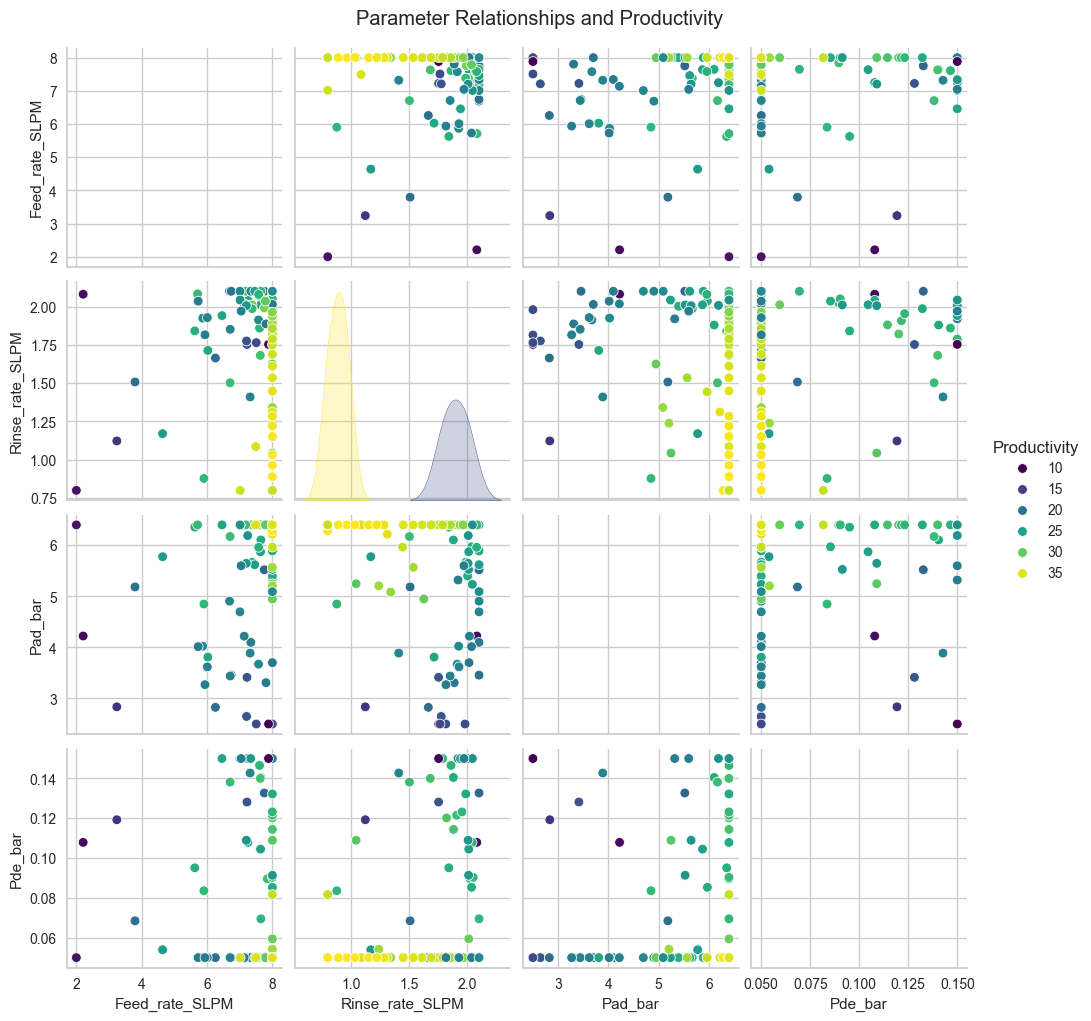

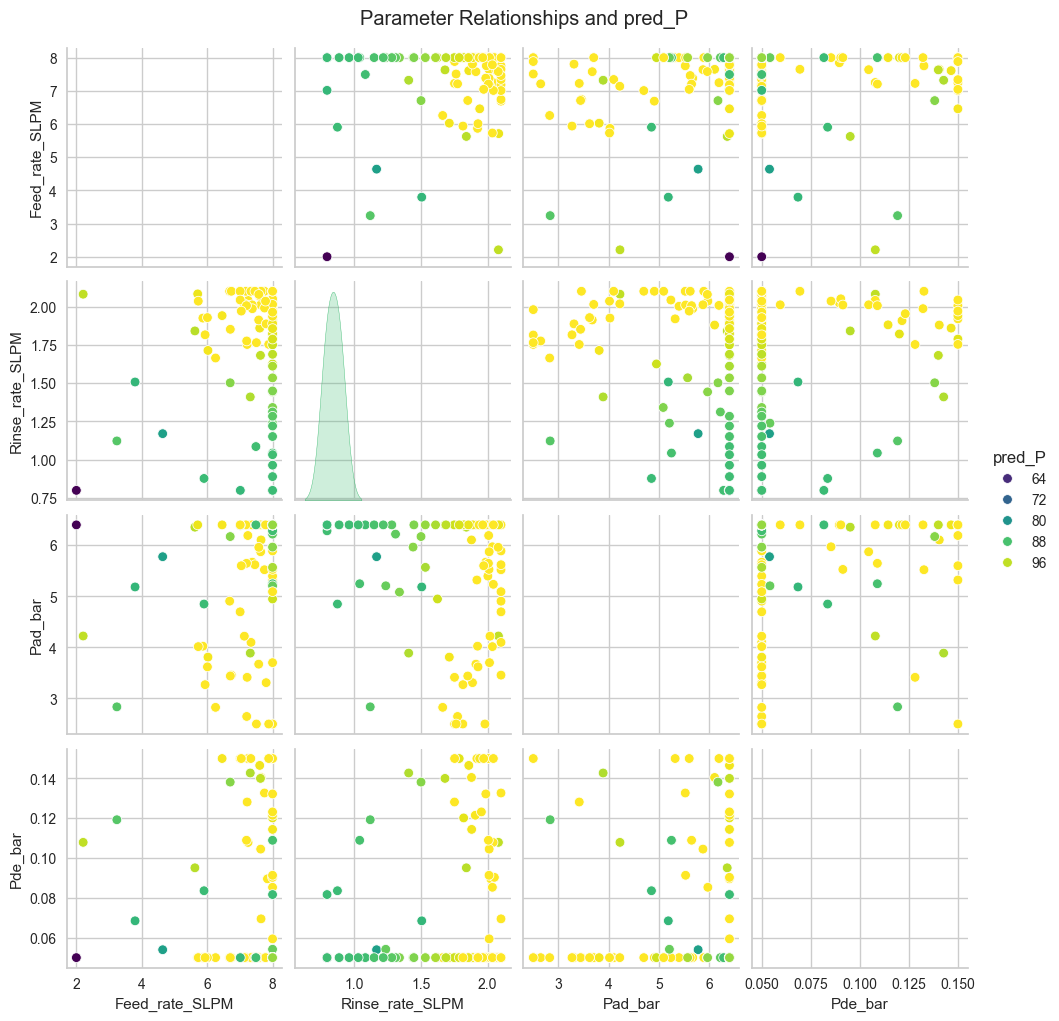

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 각 Objective 값의 변화 추이 (objectives_list 자동 사용)
for obj in objectives_list:
    plt.figure(figsize=(8,4))
    plt.plot(history_df[obj], marker='o', label='Progress')
    
    # 각 objective의 최대값을 별 마크로 표기
    max_val = history_df[obj].max()
    max_idx = history_df[obj].idxmax()
    plt.plot(max_idx, max_val, marker='*', markersize=15, color='red', label=f'Max: {max_val:.4f}')
    
    plt.xlabel('Trial')
    plt.ylabel(obj)
    plt.title(f'{obj} Progression')
    plt.legend()
    plt.show()

# 2. 파라미터별 각 Objective 값 분포
param_names = ['Feed_rate_SLPM', 'Rinse_rate_SLPM', 'Pad_bar', 'Pde_bar']
for obj in objectives_list:
    for param in param_names:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=history_df, x=param, y=obj, label='Points')
        
        # 각 objective의 최대값을 별 마크로 표기
        max_val = history_df[obj].max()
        max_row = history_df[history_df[obj] == max_val].iloc[0]
        plt.plot(max_row[param], max_val, marker='*', markersize=15, color='red', label=f'Max: {max_val:.4f}')
        
        plt.title(f'{obj} vs {param}')
        plt.legend()
        plt.show()

# 3. Pairplot (Objective별 색상)
for obj in objectives_list:
    sns.pairplot(history_df, vars=param_names, hue=obj, palette='viridis')
    plt.suptitle(f'Parameter Relationships and {obj}', y=1.02)
    plt.show()